In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.transforms import Bbox
from sqlalchemy import create_engine
from configparser import ConfigParser
import random
import numpy as np
import math

In [2]:
import matplotlib.patheffects as PathEffects

In [3]:
config = ConfigParser()
config.read("setting.ini")
dbsett = config["eurodeer_db"]
eu_bbox = ["-24.2","35.2","43.4","71.0"]

In [4]:
# create connection with eurodeer_db
db_connection_url = "postgresql://{us}:{pas}@{host}:{port}/{db}".format(us=dbsett['user'],
                                                                      pas=dbsett['password'],
                                                                      host=dbsett['host'],
                                                                      port=dbsett['port'],
                                                                      db=dbsett["db"]
                                                                     )
con = create_engine(db_connection_url)
eu_sql = "select id, research_group_name as name, geom from main.view_reasearch_groups_euromammals where geom @ ST_MakeEnvelope ({bbox}, 4326) order by st_y(geom)".format(bbox=','.join(eu_bbox))
eu_df = gpd.GeoDataFrame.from_postgis(eu_sql, con)
noneu_sql = "select id, research_group_name as name, geom from main.view_reasearch_groups_euromammals where not ST_Contains(ST_MakeEnvelope ({bbox}, 4326), geom) order by st_y(geom)".format(bbox=",".join(eu_bbox))
noneu_df = gpd.GeoDataFrame.from_postgis(noneu_sql, con)

In [5]:
# function for calculate angle between two points
def angle_between(p1, p2):
    ang1 = np.arctan2(*p1[::-1])
    ang2 = np.arctan2(*p2[::-1])
    return np.rad2deg((ang1 - ang2) % (2 * np.pi))

In [6]:
#Calculate azimuth function
def azimuthAngle( x1, y1, x2, y2):
  angle = 0.0;
  dx = x2 - x1
  dy = y2 - y1
  if x2 == x1:
    angle = math.pi / 2.0
    if y2 == y1 :
      angle = 0.0
    elif y2 < y1 :
      angle = 3.0 * math.pi / 2.0
  elif x2 > x1 and y2 > y1:
    angle = math.atan(dx / dy)
  elif x2 > x1 and y2 < y1 :
    angle = math.pi / 2 + math.atan(-dy / dx)
  elif x2 < x1 and y2 < y1 :
    angle = math.pi + math.atan(dx / dy)
  elif x2 < x1 and y2 > y1 :
    angle = 3.0 * math.pi / 2.0 + math.atan(dy / -dx)
  return (angle * 180 / math.pi)

In [22]:
def annotate(axes,boxes,data,**kwargs):
    #slide should be relevant edge of bbox - e.g. (0,0) for left, (0,1) for bottom ...
    try: slide = kwargs.pop("slide")
    except KeyError: slide = None
    try: 
        xytexts = kwargs.pop("xytexts")
        xytext  = xytexts
    except KeyError: 
        xytext = (0,2)
        xytexts = None
    try: boxes = kwargs.pop("boxes")
    except KeyError: boxes = list()
    pixel_diff = 1
    newlabs = []
    i=0
    for idx, row in eu_df.iterrows():
        try: 
            len(xytexts[i])
            xytext = xytexts[i]
        except TypeError: pass

        a = axes.annotate(row.name,xy=(row.geom.x, row.geom.y),textcoords='offset pixels',
                                    xytext=xytext,**kwargs)
        newlabs.append(a)
        i += 1
    plt.draw()
    i=0
    for idx, row in eu_df.iterrows():
        cbox = a.get_window_extent()
        if slide is not None:
            direct  = int((slide[0] - 0.5)*2)
            current = -direct*float("inf")
            arrow = False
            while True:
                overlaps = False
                count = 0
                for box in boxes:
                    if cbox.overlaps(box):
                        if direct*box.get_points()[slide] > direct*current:
                            overlaps = True
                            current =  box.get_points()[slide] 
                            shift   = direct*(current - cbox.get_points()[1-slide[0],slide[1]])
                if not overlaps: break
                arrow = True
                position = array(a.get_position())
                position[slide[1]] += shift * direct * pixel_diff
                a.set_position(position)
                plt.draw()
                cbox = a.get_window_extent()
                x,y =  axes.transData.inverted().transform(cbox)[0]
            if arrow:
                axes.arrow(x,y,data[i][0]-x,data[i][1]-y,head_length=0,head_width=0)
        boxes.append(cbox)
        i += 1
    plt.draw()
    return boxes

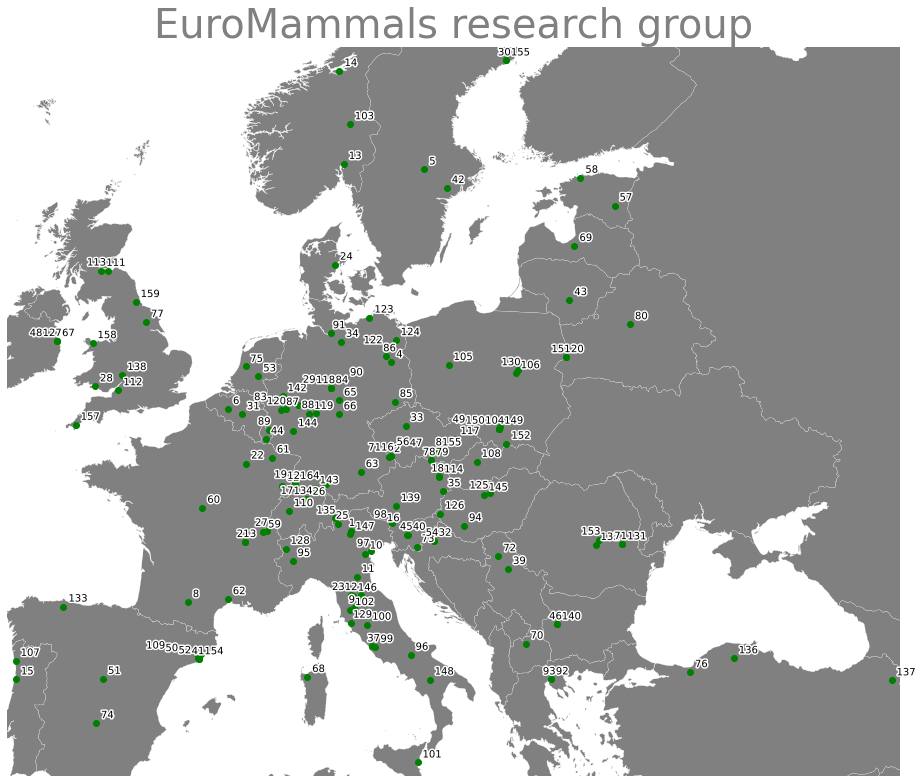

In [25]:
text_rectangles=[]
step = 0.5
minx, miny, maxx, maxy = eu_df.geometry.total_bounds
fig, ax = plt.subplots(figsize=(16,16))
gdf = gpd.read_file("data/ne_10m_admin_0_sovereignty.shp")
gdf.plot(ax=ax, color="grey", edgecolor="white", linewidth=0.2)
eu_df.plot(ax=ax, color="green")
plt.title("EuroMammals research group", fontsize=40, color="grey")
ax.axis("off")
ax.set_xlim(minx-0.5, maxx+0.5)
ax.set_ylim(miny-0.5, maxy+0.5)
#eu_df["sort_key"] = [coord.y  for coord in eu_df.geometry]
#eu_df.sort_values("sort_key", ascending=False, inplace=True)
#del eu_df["sort_key"]

for idx, row in eu_df.iterrows():
    text = ax.annotate(text=row.id, xy=(row.geom.x,row.geom.y),xytext=(5,5), textcoords='offset points',
                       path_effects=[PathEffects.withStroke(linewidth=3, foreground="w")])
    startx, starty = text.get_position()
    rect = text.get_window_extent()
    for other_rect in text_rectangles:
        while Bbox.intersection(rect, other_rect):  # overlapping
            x, y = text.get_position()
            azimuth = azimuthAngle(startx, starty, x, y)
            if azimuth < 90:
                text.set_position((x, y - step))
            elif azimuth < 180:
                text.set_position((x - step, y))
            elif azimuth < 270:
                text.set_position((x - step, y + step))
            else:
                text.set_position((x - step, y - step))
            rect = text.get_window_extent()
    text_rectangles.append(rect)
    

plt.show()

In [ ]:
text_rectangles=[]
step = 0.5
minx, miny, maxx, maxy = eu_df.geometry.total_bounds
fig, ax = plt.subplots(figsize=(16,16))
gdf = gpd.read_file("data/ne_10m_admin_0_sovereignty.shp")
gdf.plot(ax=ax, color="grey", edgecolor="white", linewidth=0.2)
eu_df.plot(ax=ax, color="green")
plt.title("EuroMammals research group", fontsize=40, color="grey")
ax.axis("off")
ax.set_xlim(minx-0.5, maxx+0.5)
ax.set_ylim(miny-0.5, maxy+0.5)


In [ ]:
for x, y, label in zip(eu_df.geometry.x, eu_df.geometry.y, eu_df.id):
    rand = random.random()
    if (index % 2) == 0:
        ax.annotate(label, xy=(x+rand, y+rand), xytext=(3, 3), textcoords="offset points")
    else:
        ax.annotate(label, xy=(x-rand, y-rand), xytext=(3, 3), textcoords="offset points")
    index+=1

In [ ]:
for idx, row in eu_df.iterrows():
    text = ax.annotate(text=row.id, xy=(row.geom.x,row.geom.y))

    rect = text.get_window_extent()

    for other_rect in text_rectangles:
        while Bbox.intersection(rect, other_rect):  # overlapping
            x, y = text.get_position()
            text.xy = (x, y - y_step)
            rect = text.get_window_extent()
    text_rectangles.append(rect)

In [ ]:
db_connection_url = "postgresql://{us}:{pas}@{host}:{port}/{db}".format(us=dbsett['user'],
                                                                      pas=dbsett['password'],
                                                                      host=dbsett['host'],
                                                                      port=dbsett['port'],
                                                                      db="eurowildcat_db"
                                                                     )
con = create_engine(db_connection_url)
eu_sql = "select research_groups_id as id, short_name, geom from main.research_groups where geom @ ST_MakeEnvelope ({bbox}, 4326) order by st_y(geom)".format(bbox=','.join(eu_bbox))
eu_df = gpd.GeoDataFrame.from_postgis(eu_sql, con)
noneu_sql = "select research_groups_id as id, short_name, geom from main.research_groups where not ST_Contains(ST_MakeEnvelope ({bbox}, 4326), geom) order by st_y(geom)".format(bbox=",".join(eu_bbox))
noneu_df = gpd.GeoDataFrame.from_postgis(noneu_sql, con)

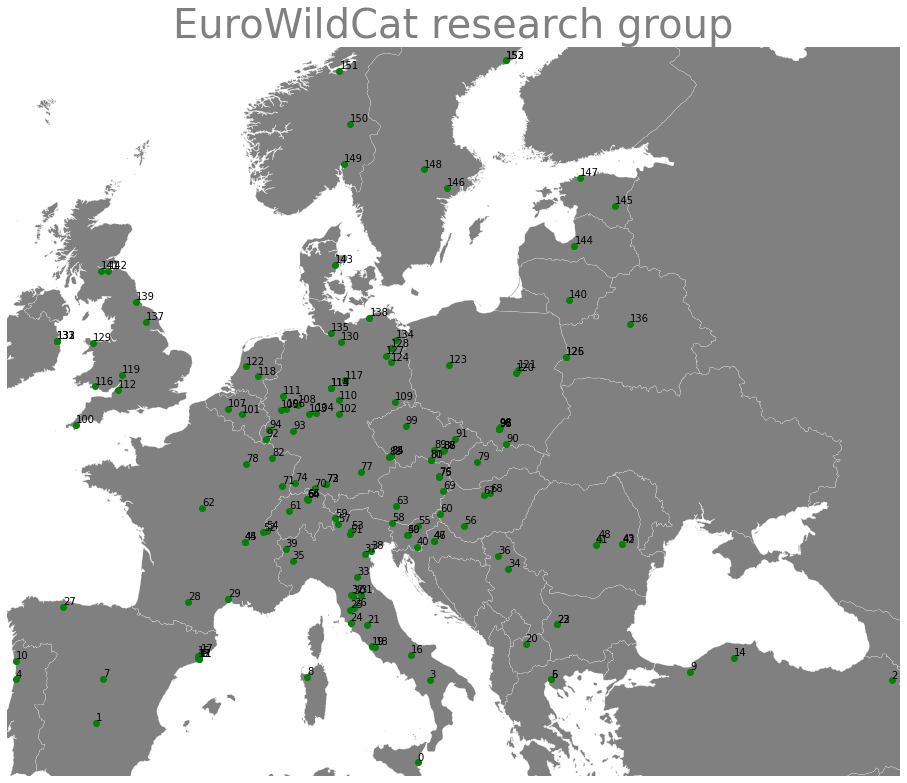

In [23]:
text_rectangles=[]
step = 0.2
minx, miny, maxx, maxy = eu_df.geometry.total_bounds
fig, ax = plt.subplots(figsize=(16,16))
gdf = gpd.read_file("data/ne_10m_admin_0_sovereignty.shp")
gdf.plot(ax=ax, color="grey", edgecolor="white", linewidth=0.2)
eu_df.plot(ax=ax, color="green")
plt.title("EuroWildCat research group", fontsize=40, color="grey")
ax.axis("off")
ax.set_xlim(minx-0.5, maxx+0.5)
ax.set_ylim(miny-0.5, maxy+0.5)
annotate(ax, text_rectangles, eu_df)
plt.show()

KeyError: 0

In [26]:
import mapnik

ModuleNotFoundError: No module named 'mapnik'